# Rafael TCC - Projeto 04
## Análise Multivariada Pareada: Selos Comerciais × Linhagens
Avaliação do confronto entre a chancela mercadológica da central (Selos Comerciais CRV) e a tradição dos criatórios e linhagens genéticas (Pedigree) na precificação do sêmen Nelore (ANCP).

### Bibliotecas

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


### Carga dos Dados e Engenharia de Variáveis (Selos + Linhagens)

In [2]:
# 1. Carregar base de touros ANCP válidos (N = 115)
df_ancp = pd.read_csv('Dados/CSV/NeloreCRV_ANCP_valido.csv')

# 2. Carregar dados gerais contendo a genealogia e criador
df_geral = pd.read_csv('Dados/CSV/NeloreCRV_Dados_Gerais.csv')
cols_genealogia = ['crv_code', 'criador', 'proprietario', 'linhagem', 'pai', 'avo_paterno', 'avo_materno']

df_sl = pd.merge(
    df_ancp, 
    df_geral[cols_genealogia], 
    left_on='CRV_COD', 
    right_on='crv_code', 
    how='inner'
)

# 3. Engenharia de Dummies dos Selos Comerciais
df_sl['SELO_IFERT'] = df_sl['SELOS'].fillna('').apply(lambda s: 1 if 'ifert' in s.lower() else 0)
df_sl['SELO_MATERNAL'] = df_sl['SELOS'].fillna('').apply(lambda s: 1 if 'maternal' in s.lower() else 0)
df_sl['SELO_CAR'] = df_sl['SELOS'].fillna('').apply(lambda s: 1 if 'car' in s.lower() else 0)
df_sl['SELO_CARCACA'] = df_sl['SELOS'].fillna('').apply(lambda s: 1 if 'carcaca' in s.lower() else 0)
df_sl['SELO_EXTENSIVO'] = df_sl['SELOS'].fillna('').apply(lambda s: 1 if 'extensivo' in s.lower() else 0)
df_sl['SELO_CONCEITO'] = df_sl['SELOS'].fillna('').apply(lambda s: 1 if 'conceito' in s.lower() else 0)

cols_selos = ['SELO_IFERT', 'SELO_MATERNAL', 'SELO_CAR', 'SELO_CARCACA', 'SELO_EXTENSIVO', 'SELO_CONCEITO']

# 4. Engenharia de Dummies dos Troncos Genéticos / Linhagens
troncos = {
    'TRONCO_EAO': lambda r: 1 if any('EAO' in str(x).upper() for x in [r['linhagem'], r['pai'], r['avo_paterno'], r['avo_materno'], r['NOME'], r['criador']]) else 0,
    'TRONCO_REM': lambda r: 1 if any('REM' in str(x).upper() for x in [r['linhagem'], r['pai'], r['avo_paterno'], r['avo_materno'], r['NOME']]) else 0,
    'TRONCO_NAVIRAI': lambda r: 1 if any(('NAVIRAI' in str(x).upper() or 'NAVIRAÍ' in str(x).upper()) for x in [r['linhagem'], r['pai'], r['avo_paterno'], r['avo_materno'], r['NOME']]) else 0,
    'TRONCO_COLONIAL': lambda r: 1 if any(('COL' in str(x).upper() or 'COLONIAL' in str(x).upper()) for x in [r['linhagem'], r['pai'], r['avo_paterno'], r['avo_materno'], r['NOME']]) else 0,
    'TRONCO_MATINHA': lambda r: 1 if any(('MAT' in str(x).upper() or 'MATINHA' in str(x).upper()) for x in [r['linhagem'], r['pai'], r['avo_paterno'], r['avo_materno'], r['NOME']]) else 0,
    'TRONCO_LEMGRUBER_MN': lambda r: 1 if any((' MN' in str(x).upper() or 'MUNDO NOVO' in str(x).upper() or 'LEMGRUBER' in str(x).upper()) for x in [r['linhagem'], r['pai'], r['avo_paterno'], r['avo_materno'], r['NOME']]) else 0,
    'TRONCO_IZ': lambda r: 1 if any(('IZ' in str(x).upper() or 'SERTÃOZINHO' in str(x).upper()) for x in [r['linhagem'], r['pai'], r['avo_paterno'], r['avo_materno'], r['NOME']]) else 0
}

for nome, func in troncos.items():
    df_sl[nome] = df_sl.apply(func, axis=1)

cols_linhagens = list(troncos.keys())

print("=" * 80)
print(f"BASE PREPARADA COM SUCESSO: N = {len(df_sl)} touros")
print(f"Total de Selos: {len(cols_selos)} | Total de Linhagens: {len(cols_linhagens)}")
print("=" * 80)

BASE PREPARADA COM SUCESSO: N = 115 touros
Total de Selos: 6 | Total de Linhagens: 7


### Random Forest Amplo (Duelo Selos vs. Linhagens)

RANKING RANDOM FOREST: DUELO SELOS × LINHAGENS


,Atributo,Tipo,Nome_Exibicao,Importância (%),Acumulado (%)
0,SELO_IFERT,Selo,Selo IFERT,27.95,27.95
1,TRONCO_EAO,Linhagem,Linhagem EAO,15.24,43.19
2,TRONCO_REM,Linhagem,Linhagem REM,10.70,53.89
3,SELO_MATERNAL,Selo,Selo MATERNAL,9.23,63.12
4,SELO_EXTENSIVO,Selo,Selo EXTENSIVO,7.29,70.41
5,TRONCO_COLONIAL,Linhagem,Linhagem COLONIAL,6.55,76.96
6,TRONCO_LEMGRUBER_MN,Linhagem,Linhagem LEMGRUBER_MN,6.49,83.45
7,TRONCO_MATINHA,Linhagem,Linhagem MATINHA,5.64,89.09
8,SELO_CARCACA,Selo,Selo CARCACA,3.27,92.36
9,TRONCO_IZ,Linhagem,Linhagem IZ,3.22,95.58


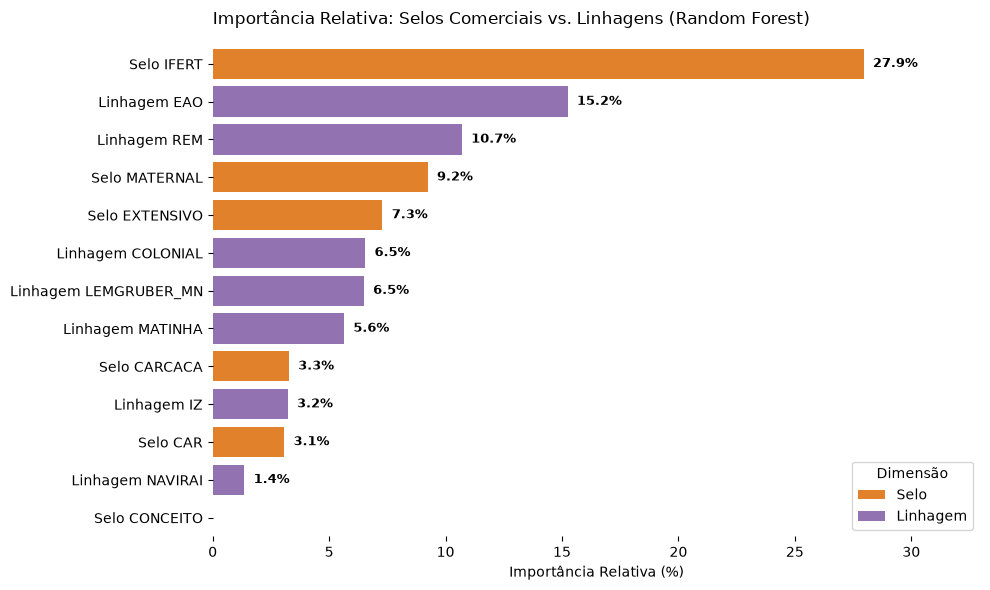

In [6]:
# 1. Preparação das features para o duelo
features_duelo = cols_selos + cols_linhagens
X_rf = df_sl[features_duelo].copy()
y = df_sl['SEMEM'].copy()

# 2. Ajuste do Random Forest (500 árvores)
rf = RandomForestRegressor(n_estimators=500, random_state=42, max_features='sqrt')
rf.fit(X_rf, y)

# 3. Tabela de Importâncias
df_imp_duelo = pd.DataFrame({
    'Atributo': features_duelo,
    'Tipo': ['Selo' if c in cols_selos else 'Linhagem' for c in features_duelo],
    'Nome_Exibicao': [c.replace('SELO_', 'Selo ').replace('TRONCO_', 'Linhagem ') for c in features_duelo],
    'Importância (%)': (rf.feature_importances_ * 100).round(2)
}).sort_values(by='Importância (%)', ascending=False).reset_index(drop=True)

df_imp_duelo['Acumulado (%)'] = df_imp_duelo['Importância (%)'].cumsum().round(2)

print("=" * 80)
print("RANKING RANDOM FOREST: DUELO SELOS × LINHAGENS")
print("=" * 80)
display(df_imp_duelo)

# 4. Gráfico de Barras Colorido por Dimensão com rótulos perfeitamente alinhados
plt.figure(figsize=(10, 6))
palette = {'Selo': '#ff7f0e', 'Linhagem': '#9467bd'}

ax = sns.barplot(
    data=df_imp_duelo,
    x='Importância (%)',
    y='Nome_Exibicao',
    hue='Tipo',
    dodge=False,
    palette=palette
)

# Alinhamento preciso: iterar sobre cada patch usando a sua própria largura e posição Y
for p in ax.patches:
    width = p.get_width()
    if width > 0.05:  # Apenas para barras com valor visível
        ax.text(
            width + 0.4, 
            p.get_y() + p.get_height() / 2, 
            f"{width:.1f}%", 
            va='center', 
            ha='left',
            fontsize=9, 
            fontweight='bold'
        )

ax.set_title('Importância Relativa: Selos Comerciais vs. Linhagens (Random Forest)', fontsize=12, loc='left', pad=15)
ax.set_xlabel('Importância Relativa (%)', fontsize=10)
ax.set_ylabel('')
ax.set_xlim(0, df_imp_duelo['Importância (%)'].max() + 5)
ax.legend(title='Dimensão', loc='lower right', frameon=True)
sns.despine(left=True, bottom=True, top=True, right=True)
plt.tight_layout()
plt.show()


### Regressão OLS Pareada (Selos × Linhagens)

In [4]:
# OLS 1: Apenas os Selos Significativos (IFERT + MATERNAL)
X_m1 = sm.add_constant(df_sl[['SELO_IFERT', 'SELO_MATERNAL']])
m_selos = sm.OLS(y, X_m1).fit()

# OLS 2: Apenas a Linhagem Significativa (TRONCO_EAO)
X_m2 = sm.add_constant(df_sl[['TRONCO_EAO']])
m_linhagem = sm.OLS(y, X_m2).fit()

# OLS 3: Modelo Conjunto Pareado (IFERT + MATERNAL + TRONCO_EAO)
X_m3 = sm.add_constant(df_sl[['SELO_IFERT', 'SELO_MATERNAL', 'TRONCO_EAO']])
m_conjunto = sm.OLS(y, X_m3).fit()

# Tabela comparativa do Duelo
tabela_duelo = pd.DataFrame([
    {
        'Modelo': '1. Apenas Selos (IFERT + MATERNAL)',
        'R² (%)': f"{m_selos.rsquared * 100:.1f}%",
        'R² Ajustado (%)': f"{m_selos.rsquared_adj * 100:.1f}%",
        'p-valor': f"{m_selos.f_pvalue:.4e}",
        'AIC': f"{m_selos.aic:.1f}"
    },
    {
        'Modelo': '2. Apenas Linhagem (TRONCO_EAO)',
        'R² (%)': f"{m_linhagem.rsquared * 100:.1f}%",
        'R² Ajustado (%)': f"{m_linhagem.rsquared_adj * 100:.1f}%",
        'p-valor': f"{m_linhagem.f_pvalue:.4e}",
        'AIC': f"{m_linhagem.aic:.1f}"
    },
    {
        'Modelo': '3. Duelo Pareado (Selos × Linhagem)',
        'R² (%)': f"{m_conjunto.rsquared * 100:.1f}%",
        'R² Ajustado (%)': f"{m_conjunto.rsquared_adj * 100:.1f}%",
        'p-valor': f"{m_conjunto.f_pvalue:.4e}",
        'AIC': f"{m_conjunto.aic:.1f}"
    }
])

print("=" * 90)
print("COMPARAÇÃO ECONOMÉTRICA: SELOS ISOLADOS vs. LINHAGEM ISOLADA vs. CONJUNTO")
print("=" * 90)
display(tabela_duelo)

print("\n" + "=" * 90)
print("SUMÁRIO DO MODELO PAREADO: SELOS × LINHAGEM")
print("=" * 90)
print(m_conjunto.summary())

COMPARAÇÃO ECONOMÉTRICA: SELOS ISOLADOS vs. LINHAGEM ISOLADA vs. CONJUNTO


,Modelo,R² (%),R² Ajustado (%),p-valor,AIC
0,1. Apenas Selos (IFERT + MATERNAL),20.5%,19.1%,2.6583e-06,745.5
1,2. Apenas Linhagem (TRONCO_EAO),7.5%,6.6%,3.1378e-03,760.9
2,3. Duelo Pareado (Selos × Linhagem),26.3%,24.3%,1.9318e-07,738.7



SUMÁRIO DO MODELO PAREADO: SELOS × LINHAGEM
                            OLS Regression Results                            
Dep. Variable:                  SEMEM   R-squared:                       0.263
Model:                            OLS   Adj. R-squared:                  0.243
Method:                 Least Squares   F-statistic:                     13.22
Date:                Tue, 29 Sep 2026   Prob (F-statistic):           1.93e-07
Time:                        00:09:55   Log-Likelihood:                -365.35
No. Observations:                 115   AIC:                             738.7
Df Residuals:                     111   BIC:                             749.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
c

### Gráfico de Barras Divergentes dos Coeficientes $\beta$ (Selos × Linhagens)

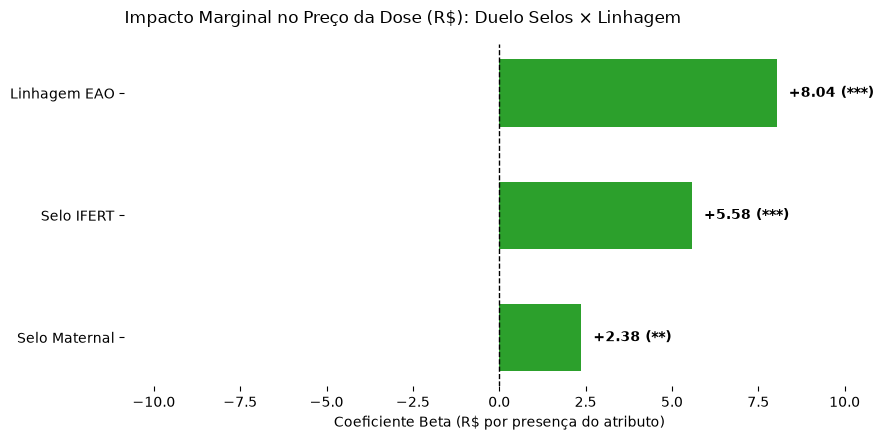

In [5]:
# Extrair coeficientes e p-valores do modelo pareado
coef_data = pd.DataFrame({
    'Variável': ['Selo IFERT', 'Selo Maternal', 'Linhagem EAO'],
    'Beta': [m_conjunto.params['SELO_IFERT'], m_conjunto.params['SELO_MATERNAL'], m_conjunto.params['TRONCO_EAO']],
    'p_valor': [m_conjunto.pvalues['SELO_IFERT'], m_conjunto.pvalues['SELO_MATERNAL'], m_conjunto.pvalues['TRONCO_EAO']]
}).sort_values(by='Beta', ascending=True).reset_index(drop=True)

cores = ['#2ca02c' if b > 0 else '#d62728' for b in coef_data['Beta']]

plt.figure(figsize=(9, 4.5))
ax = plt.subplot(111)
barras = ax.barh(coef_data['Variável'], coef_data['Beta'], color=cores, height=0.55, edgecolor='none')

ax.axvline(0, color='black', linewidth=1, linestyle='--')

for bar, beta, p in zip(barras, coef_data['Beta'], coef_data['p_valor']):
    sig = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.10 else 'ns'))
    texto = f" {beta:+.2f} ({sig})"
    if beta >= 0:
        ax.text(beta + 0.2, bar.get_y() + bar.get_height()/2, texto, va='center', ha='left', fontsize=10, fontweight='bold')
    else:
        ax.text(beta - 0.2, bar.get_y() + bar.get_height()/2, texto, va='center', ha='right', fontsize=10, fontweight='bold')

limite = max(abs(coef_data['Beta'])) * 1.35
ax.set_xlim(-limite, limite)
ax.set_title('Impacto Marginal no Preço da Dose (R$): Duelo Selos × Linhagem', fontsize=12, loc='left', pad=15)
ax.set_xlabel('Coeficiente Beta (R$ por presença do atributo)', fontsize=10)
sns.despine(left=True, bottom=True, top=True, right=True)
plt.tight_layout()
plt.show()
